# DZO Assignment: Linear and Nonlinear Filtering 

The two following labs deal with filtration of images, which can be used for smoothing, deblurring, denoising and other applications.

### 1. 2D convolution using loops 
The very first task will be to implement 2D convolution. This is done in function `convolve2d` in the template `.py` file. 
Use the well known formula for convolution of `im` and `kernel`: 
$$
\tt r[s, t] = \sum_{x}\sum_{y} im[s-x, s-y] \ kernel[x, y] 
$$
Note you will have to think about three things:
* size of result. There are three usual options: Compute the convolution 1) at all points for which there is an overlap between `im` and `kernel`; 2) at all points of the original image; 3) only at points where kernel is fully contained in an image. These are usually named 'full', 'same' and 'valid'. Of these, we will go with 'same'.  
* coordinate systems: make sure that `r` is the same as `im` when convolved with identity kernel. It will help to think about the center of `kernel` to have coordinates `(0,0)`
* boundaries: whenever part of the kernel goes outside of the image, it must be defined what values should be used for computing the convolution at points outside the image support. You will use the 'extend' option which is illustrated e.g. [here](https://en.wikipedia.org/wiki/Kernel_(image_processing)#Edge_handling).

Furthermore, 
* Your code will have 4 nested loops. The inner-most loop will perform multiplication between exactly one kernel element and one image element. 


In [1]:
%load_ext autoreload
%autoreload 2

from filtering import *
from DZO.utils import load_test_image, imread

import numpy as np
from numpy.fft import fft2, ifft2, fftshift, ifftshift

import matplotlib.pyplot as plt

# set the default fixed size for figures so that they are not as big as the default:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (3,3)

We'll make several toy examples. First of all, make sure that convolution with an identity kernel produces the original image. 

Text(0.5, 1.0, 'convolution with identity')

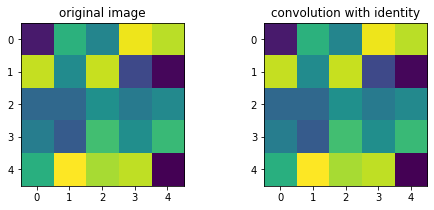

In [2]:
im = np.random.rand(5,5)

kernel = np.zeros((3, 3))
kernel[1,1] = 1.0

r = convolve2d(im, kernel)
plt.figure(figsize=(8, 3))
plt.subplot(1,2,1); plt.imshow(im); plt.title('original image')
plt.subplot(1,2,2); plt.imshow(r); plt.title('convolution with identity')


Next, let us make a non-trivial kernel. 

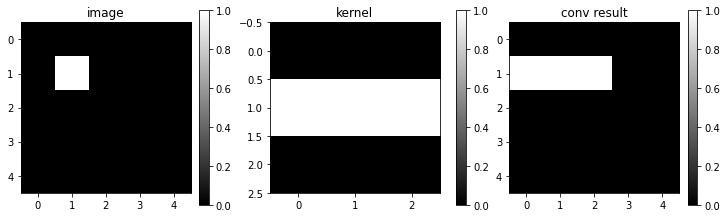

In [3]:
im = np.zeros((5, 5))
im[1, 1] = 1

kernel = np.zeros((3, 3))
kernel[1, :] = 1.0 

r = convolve2d(im, kernel)

show_tuple([im, kernel, r])

Make sure the boundaries are handled correctly. In our case, that they are extended as explained above. 

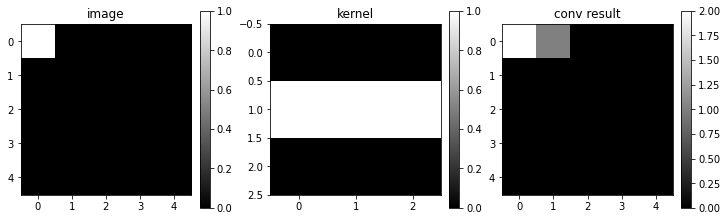

In [4]:
im = np.zeros((5, 5))
im[0, 0] = 1

kernel = np.zeros((3, 3))
kernel[1, :] = 1.0 

r = convolve2d(im, kernel)
show_tuple([im, kernel, r])
# make sure you understand why r[0, 0] is 2.0

### 2. Create useful kernels 

Here you will implement average kernel and then also Gaussian, x-derivative of Gaussian, y-derivative of Gaussian, and Laplace. 

You may find this [PDF](https://cw.fel.cvut.cz/wiki/_media/courses/dzo/l04.pdf) useful for reference. 


1.0


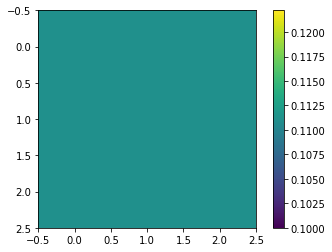

In [5]:
K = get_kernel('average', half_size = 1)
plt.imshow(K); plt.colorbar()
print(K.sum())

1.0


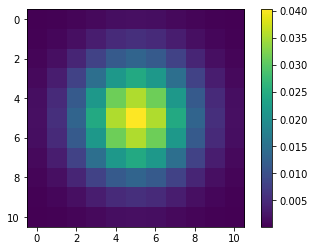

In [6]:
# Gaussian
K = get_kernel('G', half_size = 5, sigma = 2)
plt.imshow(K); plt.colorbar()
print(K.sum())


-4.0766001685454967e-17
23.668785707804204


Text(0.5, 1.0, 'X slope')

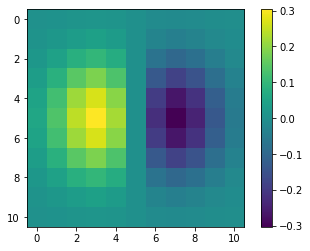

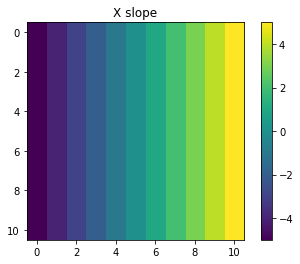

In [7]:
# x-derivative of Gaussian
half_size = 5
K = get_kernel('Gx', half_size = half_size, sigma = 2)
plt.imshow(K); plt.colorbar()


print(K.sum()) # this should be close to zero. 

# if properly scaled, derivative on a unit slope should be 1. 
X_slope = np.stack( ( np.arange(-half_size, half_size+1), )*(2*half_size+1), axis = 0)
print((-X_slope * K).sum()) # this should be close to 1 
plt.figure()
plt.imshow(X_slope); plt.colorbar(); plt.title('X slope')


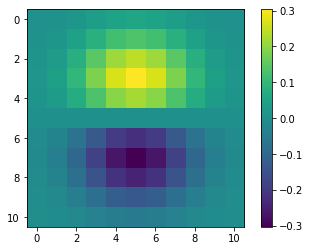

In [8]:
# y-derivative of Gaussian
half_size = 5
K = get_kernel('Gy', half_size = half_size, sigma = 2)
plt.imshow(K); plt.colorbar()

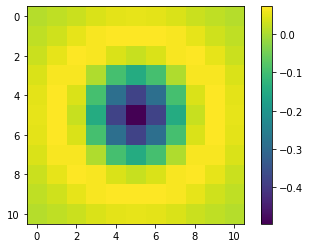

In [9]:
# Laplace 
half_size = 5
K = get_kernel('L', half_size = half_size, sigma = 2)
plt.imshow(K); plt.colorbar()


### Making the loops faster with Numba



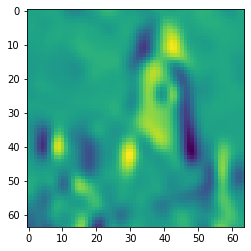

In [10]:

im = imread('lighthouse_64x64.png', convert_to_gray=True).astype(float)
K = get_kernel('Gx', half_size = 5, sigma = 2)
r = convolve2d(im, K)
plt.imshow(r)


In [11]:
import time
N_runs = 3
t0 = time.time()
for k in range(N_runs): 
    r = convolve2d(im, K)
t1 = time.time()
average_slow = (t1-t0)/N_runs
print(f'average time to compute convolve2d: {average_slow}')

average time to compute convolve2d: 0.23123796780904135


In [12]:
# use the compiled function:
convolve2d_faster(im[:3,:3], K) # dry run (compile)

N_runs = 10
t0 = time.time()
for k in range(N_runs): 
    r = convolve2d_faster(im, K)
t1 = time.time()
average_fast = (t1-t0)/N_runs
print(f'average time to compute convolve2d: {average_fast}')
print(f'SPEEDUP: {average_slow/average_fast:.1f}')

print(f'Note: These times seem to depend a lot on state of VS Code and other.') 


average time to compute convolve2d: 0.02393982410430908
SPEEDUP: 9.7
Note: These times seem to depend a lot on state of VS Code and other.


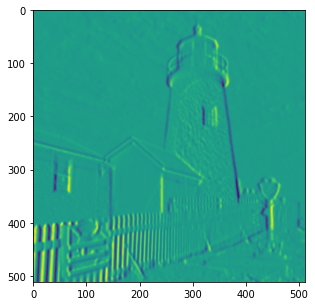

In [13]:
# with fast function, we can do convolutions even with fullres images
im = load_test_image('lighthouse.png').mean(axis=2).astype(float)
convolve2d_faster(im[:3,:3], K) # dry run

r = convolve2d_faster(im, K)

# from now on, we will appreciate bigger figures by default 
matplotlib.rcParams['figure.figsize'] = (5,5)
plt.imshow(r)


### 2. Circular convolution using FFT 

Here you will implement convolution based on Convolution Theorem (and therefore, FFT2.)


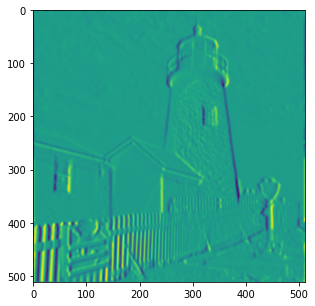

In [14]:
im = load_test_image('lighthouse.png').mean(axis=2).astype(float)
K = get_kernel('Gx', 5, sigma = 2.0)
r_ft = convolve2d_ft(im, K)

plt.imshow(r_ft)

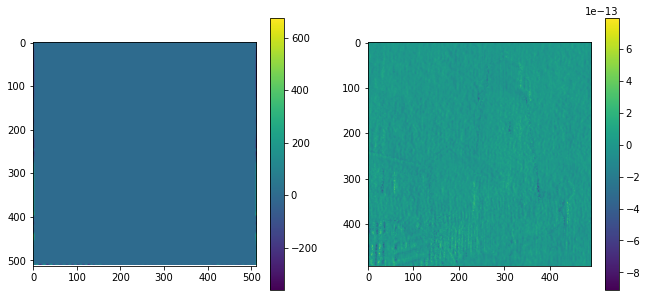

In [15]:
# if implemented correctly, the difference between the spatial-domain convolution and FT-based convolution
# will be only on the edges of the image (due to different boundary treatment)
plt.figure(figsize=(11, 5))
plt.subplot(1, 2, 1); plt.imshow(r_ft - r); plt.colorbar()
plt.subplot(1, 2, 2); plt.imshow( (r_ft - r)[10:-10, 10:-10] ); plt.colorbar()

### 3. Separable kernels 

Here you will implement the following separable kernels: average, Gaussian, x-derivative of Gaussian, and y-derivative of Gaussian. 


In [16]:
# average
k_x, k_y = get_kernel_sep('average', half_size = 1)
print('k_x:\n', k_x)
print('k_y:\n', k_y)
print('matrix product:\n', k_y @ k_x)
print('difference from 2d average kernel:\n', k_y @ k_x - get_kernel('average', half_size = 1))


k_x:
 [[0.33333333 0.33333333 0.33333333]]
k_y:
 [[0.33333333]
 [0.33333333]
 [0.33333333]]
matrix product:
 [[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]
difference from 2d average kernel:
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


k_x:
 [[0.00881223 0.02714358 0.06511406 0.12164907 0.17699836 0.20056541
  0.17699836 0.12164907 0.06511406 0.02714358 0.00881223]]
k_y.T:
 [[0.00881223 0.02714358 0.06511406 0.12164907 0.17699836 0.20056541
  0.17699836 0.12164907 0.06511406 0.02714358 0.00881223]]


Text(0.5, 1.0, 'kernel computed as 2D')

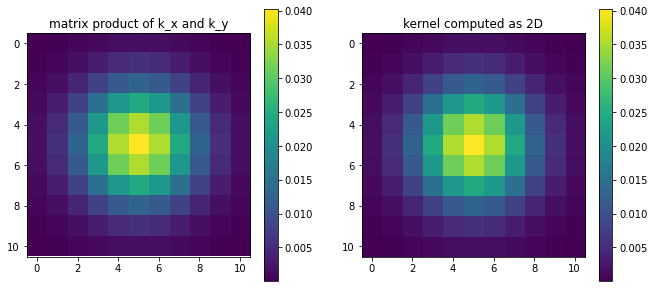

In [17]:
# Gaussian
k_x, k_y = get_kernel_sep('G', half_size = 5, sigma = 2.0)
print('k_x:\n', k_x)
print('k_y.T:\n', k_y.T)

plt.figure(figsize=(11, 5))
plt.subplot(1,2,1); plt.imshow(k_y @ k_x); plt.colorbar(); plt.title('matrix product of k_x and k_y') 
plt.subplot(1,2,2); plt.imshow( get_kernel('G', half_size = 5, sigma = 2.0) ); plt.colorbar(); plt.title('kernel computed as 2D') 


Text(0.5, 1.0, 'difference')

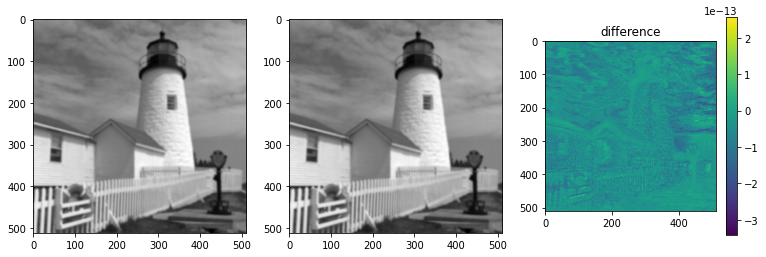

In [18]:
# let's use these on our test image: 
im = load_test_image('lighthouse.png').mean(axis=2).astype(float)

K = get_kernel('G', half_size = 5, sigma = 2.0)
r = convolve2d_faster(im, K)

k_x, k_y = get_kernel_sep('G', half_size = 5, sigma = 2.0)
r_sep = convolve2d_faster( convolve2d_faster(im, k_x), k_y ) 

# compare the results 
plt.figure(figsize=(13,4))
plt.subplot(1, 3, 1); plt.imshow(r, cmap='gray')
plt.subplot(1, 3, 2); plt.imshow(r_sep, cmap='gray')
plt.subplot(1, 3, 3); plt.imshow(r - r_sep); plt.colorbar(); plt.title('difference')


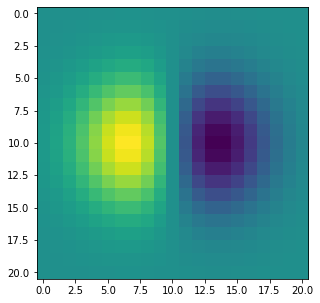

In [19]:
# Show also other implemented separable filters: 
half_size, sigma  = 10, 3.5
kernel_x, kernel_y =  get_kernel_sep('Gx', half_size = half_size, sigma = sigma)
plt.imshow(kernel_y @ kernel_x)


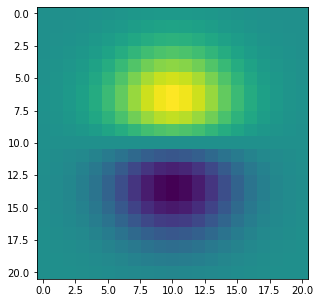

In [20]:
# Show also other implemented separable filters: 
half_size, sigma  = 10, 3.5
kernel_x, kernel_y =  get_kernel_sep('Gy', half_size = half_size, sigma = sigma)
plt.imshow(kernel_y @ kernel_x)


### 4. Wiener filtration 

Here you will implement de-convolution using Wiener Filtering. This will be used to de-blur an image. 

Text(0.5, 1.0, 'blurred image')

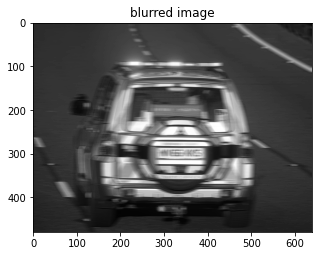

In [21]:
# toy example: 
im = imread('car.jpg', convert_to_gray = True).astype(float)

# bluring kernel: 
k = np.ones((1, 15)); k /= k.sum()
# blur the image: 
blurred = convolve2d_faster(im, k)
plt.imshow(blurred, cmap='gray'); plt.title('blurred image')

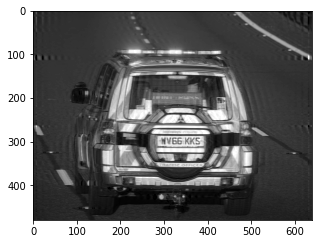

In [22]:
# try to remove the blur using Wiener filter: 
lam = 1e-2 # try different regularization constants
reconstructed = wiener_filtration(blurred, k, lam = lam)
plt.imshow(reconstructed, cmap='gray', vmin=0.0, vmax=255.0) # why do we specify vmin and vmax for viewing here? 


### 5. Bilateral filter 

Here you will implement the bilateral filter. 
You may find this [lecture PDF](https://cw.fel.cvut.cz/wiki/_media/courses/dzo/l05.pdf) useful for reference. 

Note that we will be again using the compiled version (Numba) for the implementation.  

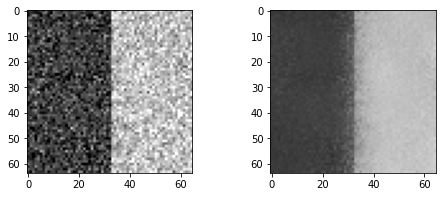

In [23]:
sigma_s = 5
sigma_b = 0.9
im = np.stack( (np.arange(-32, 33) > 0,) * 64, axis=0).astype(float) 
M, N = im.shape
im += .3*np.random.randn(M, N)

# compute spatial kernel: 
kernel_s = get_kernel('G', half_size = int(np.ceil(2.5*sigma_s)), sigma = sigma_s)
# dry run (compile)
bilateral_filter(im[:10, :10], kernel_s[:3, :3], sigma_b = sigma_b)

filtered = bilateral_filter(im, kernel_s, sigma_b = sigma_b)
plt.figure(figsize = (8, 3))
plt.subplot(1, 2, 1); plt.imshow(im, cmap='gray', vmin=-.5, vmax = 1.5)
plt.subplot(1, 2, 2); plt.imshow(filtered, cmap='gray', vmin=-.5, vmax = 1.5)


## Submission to BRUTE 

Implement the required functions into the `fourier.py` file. Submit both your `fourier.py` and `fourier.ipynb` files (zipped) to BRUTE.  

